# Этап 1 — EDA и препроцессинг

Датасет: MovieLens ml-1m.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Загрузка данных

In [2]:
DATA_DIR = "../data/raw/ml-1m"

ratings = pd.read_csv(
    f"{DATA_DIR}/ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "item_id", "rating", "timestamp"],
    encoding="latin-1",
)

movies = pd.read_csv(
    f"{DATA_DIR}/movies.dat",
    sep="::",
    engine="python",
    names=["item_id", "title", "genres"],
    encoding="latin-1",
)

users = pd.read_csv(
    f"{DATA_DIR}/users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"],
    encoding="latin-1",
)

ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

print(ratings.shape, movies.shape, users.shape)
ratings.head()

(1000209, 5) (3883, 3) (6040, 5)


,user_id,item_id,rating,timestamp,datetime
0,1,1193,5,978300760,2000-12-31 22:12:40
1,1,661,3,978302109,2000-12-31 22:35:09
2,1,914,3,978301968,2000-12-31 22:32:48
3,1,3408,4,978300275,2000-12-31 22:04:35
4,1,2355,5,978824291,2001-01-06 23:38:11


## Распределение рейтингов и временной диапазон

Временной диапазон: 2000-04-25 23:05:32 -> 2003-02-28 17:49:50


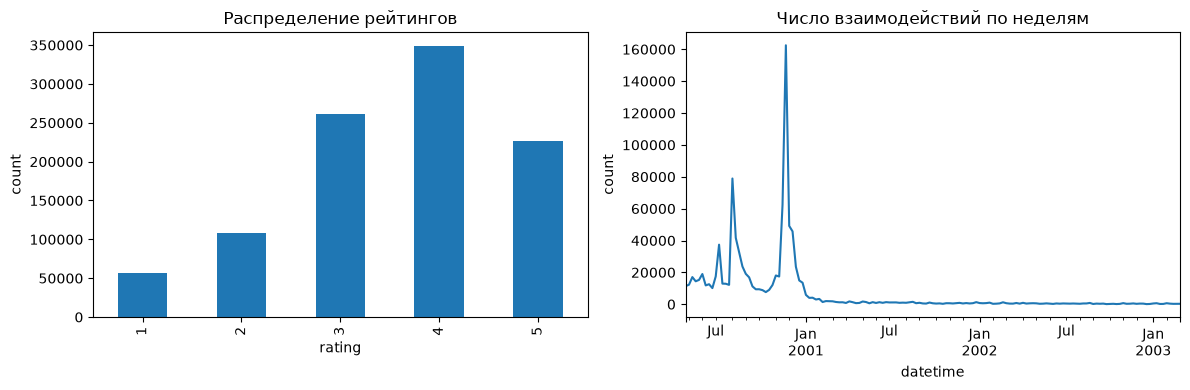

In [3]:
print("Временной диапазон:", ratings["datetime"].min(), "->", ratings["datetime"].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Распределение рейтингов")
axes[0].set_xlabel("rating")
axes[0].set_ylabel("count")

ratings.set_index("datetime").resample("W").size().plot(ax=axes[1])
axes[1].set_title("Число взаимодействий по неделям")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Sparsity матрицы user-item

Классическая проблема RecSys: подавляющее большинство пар (user, item) никогда не наблюдались.

In [4]:
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
n_interactions = len(ratings)

sparsity = 1 - n_interactions / (n_users * n_items)

print(f"Пользователей: {n_users}")
print(f"Товаров: {n_items}")
print(f"Взаимодействий: {n_interactions}")
print(f"Sparsity: {sparsity:.4%}")

Пользователей: 6040
Товаров: 3706
Взаимодействий: 1000209
Sparsity: 95.5316%


## Long-tail активности (пользователи и товары)

Ключевое для понимания popularity bias и cold start: часть пользователей/товаров имеет много взаимодействий, огромный хвост — единицы.

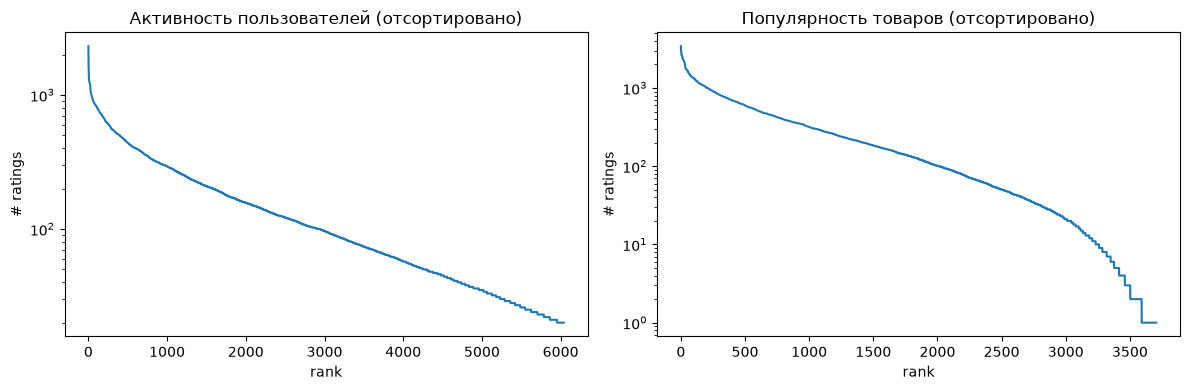

Медиана рейтингов на пользователя: 96, min: 20, max: 2314
Медиана рейтингов на товар: 124, min: 1, max: 3428
Топ-10% товаров дают 44.4% всех взаимодействий


In [5]:
user_activity = ratings.groupby("user_id").size().sort_values(ascending=False)
item_popularity = ratings.groupby("item_id").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(len(user_activity)), user_activity.values)
axes[0].set_title("Активность пользователей (отсортировано)")
axes[0].set_xlabel("rank")
axes[0].set_ylabel("# ratings")
axes[0].set_yscale("log")

axes[1].plot(np.arange(len(item_popularity)), item_popularity.values)
axes[1].set_title("Популярность товаров (отсортировано)")
axes[1].set_xlabel("rank")
axes[1].set_ylabel("# ratings")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Медиана рейтингов на пользователя: {user_activity.median():.0f}, min: {user_activity.min()}, max: {user_activity.max()}")
print(f"Медиана рейтингов на товар: {item_popularity.median():.0f}, min: {item_popularity.min()}, max: {item_popularity.max()}")
print(f"Топ-10% товаров дают {item_popularity.head(n_items // 10).sum() / n_interactions:.1%} всех взаимодействий")

## Explicit → implicit сигнал

MovieLens даёт только explicit рейтинги (1-5), реального implicit-лога (клик/просмотр) в датасете нет.
Для two-stage retrieval+ranking пайплайна нужен implicit-сигнал для candidate generation (ALS/Two-Tower обычно работают с бинарным "было взаимодействие / не было").

Порог бинаризации: **rating >= 4 → позитив**. Это эмуляция, не настоящий implicit-сигнал — явно фиксируем это допущение, чтобы не выдавать за реальный клиентский лог.

In [6]:
POSITIVE_THRESHOLD = 4

ratings["is_positive"] = (ratings["rating"] >= POSITIVE_THRESHOLD).astype(int)

print(ratings["is_positive"].value_counts(normalize=True))

is_positive
1    0.575161
0    0.424839
Name: proportion, dtype: float64


## Time-based split

Разбиваем строго по времени, не случайно — иначе data leakage (обучение на будущих взаимодействиях, тест на прошлых).

Берём глобальную временную точку отсечения (не per-user), это стандартный подход для offline-оценки RecSys: train — всё до `cutoff`, test — всё после.

In [7]:
cutoff = ratings["timestamp"].quantile(0.8)
cutoff_dt = pd.to_datetime(cutoff, unit="s")

train = ratings[ratings["timestamp"] < cutoff].copy()
test = ratings[ratings["timestamp"] >= cutoff].copy()

print(f"Cutoff: {cutoff_dt}")
print(f"Train: {len(train)} ({len(train) / len(ratings):.1%})")
print(f"Test: {len(test)} ({len(test) / len(ratings):.1%})")

# cold-start check: сколько юзеров/айтемов в test отсутствуют в train
cold_users = set(test["user_id"]) - set(train["user_id"])
cold_items = set(test["item_id"]) - set(train["item_id"])

print(f"Cold-start пользователей в test: {len(cold_users)} ({len(cold_users) / test['user_id'].nunique():.1%})")
print(f"Cold-start товаров в test: {len(cold_items)} ({len(cold_items) / test['item_id'].nunique():.1%})")

Cutoff: 2000-12-02 14:52:18
Train: 800164 (80.0%)
Test: 200045 (20.0%)
Cold-start пользователей в test: 640 (35.9%)
Cold-start товаров в test: 44 (1.3%)


## Popularity baseline

Тривиальная модель: рекомендовать всем одинаковый top-k самых популярных (по числу позитивных взаимодействий в train) товаров. Без сравнения с этим baseline нельзя доказать, что ALS/Two-Tower (этап 2) вообще дают выигрыш.

Ground truth для каждого пользователя в test — товары, которые он оценил положительно (`is_positive == 1`) после cutoff.

In [8]:
def recall_at_k(recommended: list, relevant: set, k: int) -> float:
    if not relevant:
        return np.nan
    top_k = set(recommended[:k])
    return len(top_k & relevant) / len(relevant)


def ndcg_at_k(recommended: list, relevant: set, k: int) -> float:
    if not relevant:
        return np.nan
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else np.nan


def evaluate_fixed_recommendation(recommended: list, test_positive: pd.DataFrame, k: int) -> dict:
    """Оценка НЕ-персонализированного списка (одного и того же для всех пользователей)."""
    relevant_by_user = test_positive.groupby("user_id")["item_id"].apply(set)
    recalls = relevant_by_user.apply(lambda relevant: recall_at_k(recommended, relevant, k))
    ndcgs = relevant_by_user.apply(lambda relevant: ndcg_at_k(recommended, relevant, k))
    return {"recall@k": recalls.mean(), "ndcg@k": ndcgs.mean(), "n_users": len(relevant_by_user)}

In [9]:
K = 10

train_positive = train[train["is_positive"] == 1]
test_positive = test[test["is_positive"] == 1]

popularity_ranking = (
    train_positive.groupby("item_id").size().sort_values(ascending=False)
)
top_k_popular = popularity_ranking.index.tolist()

metrics = evaluate_fixed_recommendation(top_k_popular, test_positive, K)
print(f"Popularity baseline @k={K}: Recall@k={metrics['recall@k']:.4f}, NDCG@k={metrics['ndcg@k']:.4f} "
      f"(оценено на {metrics['n_users']} пользователях с >=1 позитивом в test)")

Popularity baseline @k=10: Recall@k=0.0417, NDCG@k=0.2180 (оценено на 1762 пользователях с >=1 позитивом в test)


## Сохранение артефактов для этапа 2

Чтобы этап 2 (candidate generation) не пересчитывал split и popularity baseline заново.

In [10]:
import os

PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

train.to_parquet(f"{PROCESSED_DIR}/train.parquet", index=False)
test.to_parquet(f"{PROCESSED_DIR}/test.parquet", index=False)
popularity_ranking.rename("n_positive").to_frame().to_parquet(f"{PROCESSED_DIR}/popularity_ranking.parquet")

print("Сохранено в", PROCESSED_DIR)
print(os.listdir(PROCESSED_DIR))

Сохранено в ../data/processed
['train.parquet', 'test.parquet', 'popularity_ranking.parquet']
